<a href="https://colab.research.google.com/github/lopezjuana/my-first-blog/blob/master/notebook_regresion_randomforest_xgboost_california.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Regresión + Random Forest + XGBoost con California Housing

Esta notebook unifica contenidos de:
- Regresión
- Árboles de decisión
- Random Forest
- XGBoost

Usando el dataset `fetch_california_housing()` de `scikit-learn`.

---

## Objetivos

En esta clase vamos a:

1. Cargar y explorar datos reales.
2. Construir modelos de regresión.
3. Evaluar métricas.
4. Comparar modelos lineales vs árboles.
5. Introducir Random Forest y XGBoost.
6. Analizar overfitting y feature importance.


## 1. Importación de librerías

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,6)


## 2. Carga del dataset California Housing

In [2]:

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X.head()


Shape X: (20640, 8)
Shape y: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



### Descripción de variables

- MedInc → ingreso medio
- HouseAge → antigüedad promedio
- AveRooms → habitaciones promedio
- AveBedrms → dormitorios promedio
- Population → población
- AveOccup → ocupación promedio
- Latitude → latitud
- Longitude → longitud


## 3. Exploración de datos

In [3]:

X.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


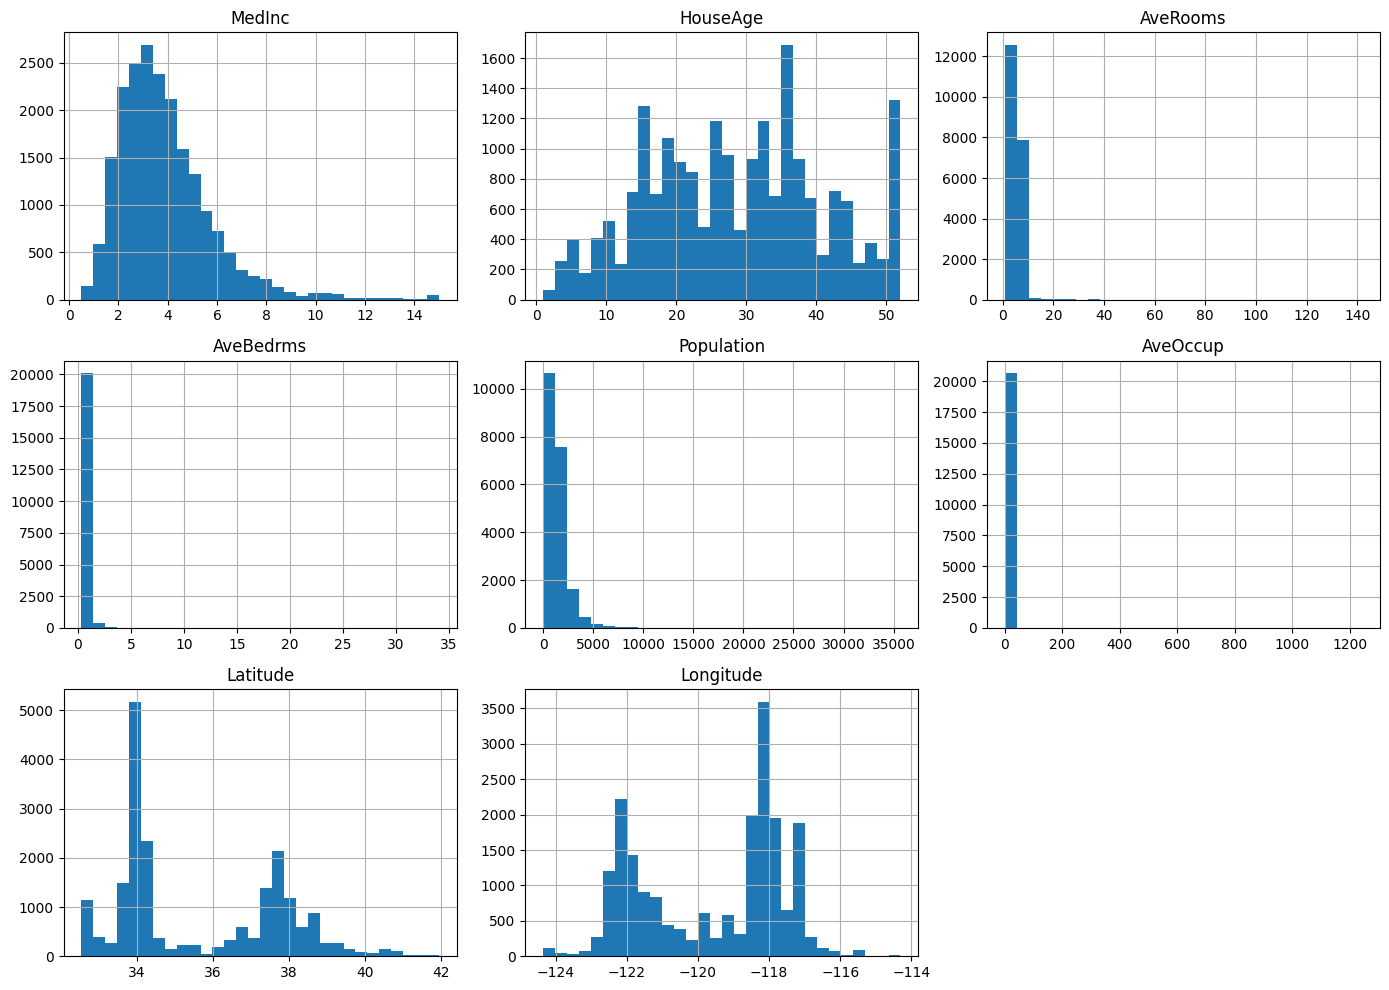

In [4]:

X.hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()


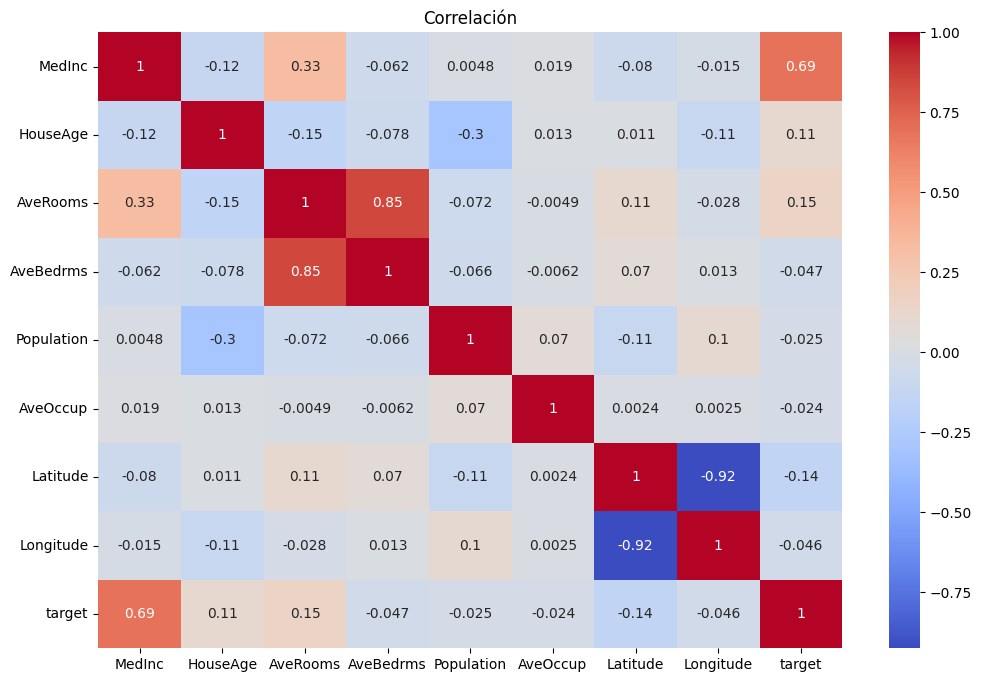

In [5]:

corr = X.copy()
corr["target"] = y

plt.figure(figsize=(12,8))
sns.heatmap(corr.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación")
plt.show()


## 4. División train/test

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (16512, 8)
Test: (4128, 8)



# 5. Regresión Lineal

Modelo base para comparar resultados.


In [7]:

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)


In [8]:

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("=== Regresión Lineal ===")
print("RMSE:", rmse_linear)
print("MAE :", mae_linear)
print("R2  :", r2_linear)


=== Regresión Lineal ===
RMSE: 0.7455813830127764
MAE : 0.5332001304956553
R2  : 0.5757877060324508


In [9]:

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": linear_model.coef_
})

coef_df.sort_values(by="Coeficiente", ascending=False)


,Variable,Coeficiente
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708



## Visualización de predicciones


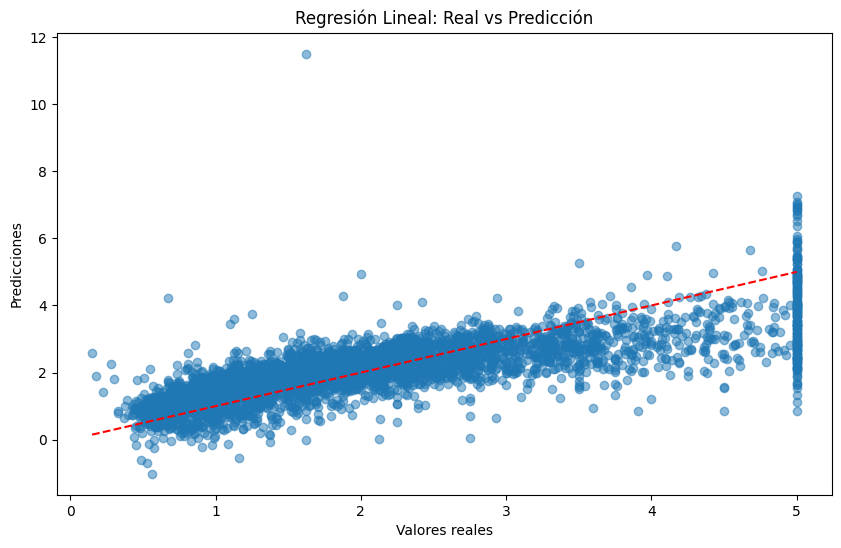

In [10]:

plt.scatter(y_test, y_pred_linear, alpha=0.5)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: Real vs Predicción")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()



# 6. Árbol de Decisión

Los árboles permiten modelar relaciones no lineales.


In [11]:

tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)


In [12]:

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("=== Árbol de Decisión ===")
print("RMSE:", rmse_tree)
print("MAE :", mae_tree)
print("R2  :", r2_tree)


=== Árbol de Decisión ===
RMSE: 0.7242338143386247
MAE : 0.5222592972077786
R2  : 0.5997321244428706



# 7. Random Forest

Random Forest combina muchos árboles de decisión.


In [13]:

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


In [14]:

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R2  :", r2_rf)


=== Random Forest ===
RMSE: 0.544511508935255
MAE : 0.36628896132800176
R2  : 0.7737402686595128



## Feature Importance - Random Forest


In [15]:

importance_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importancia",
    ascending=False
)

importance_rf


,Variable,Importancia
0,MedInc,0.593805
5,AveOccup,0.139759
6,Latitude,0.076593
7,Longitude,0.076106
1,HouseAge,0.047921
2,AveRooms,0.031539
4,Population,0.017260
3,AveBedrms,0.017017


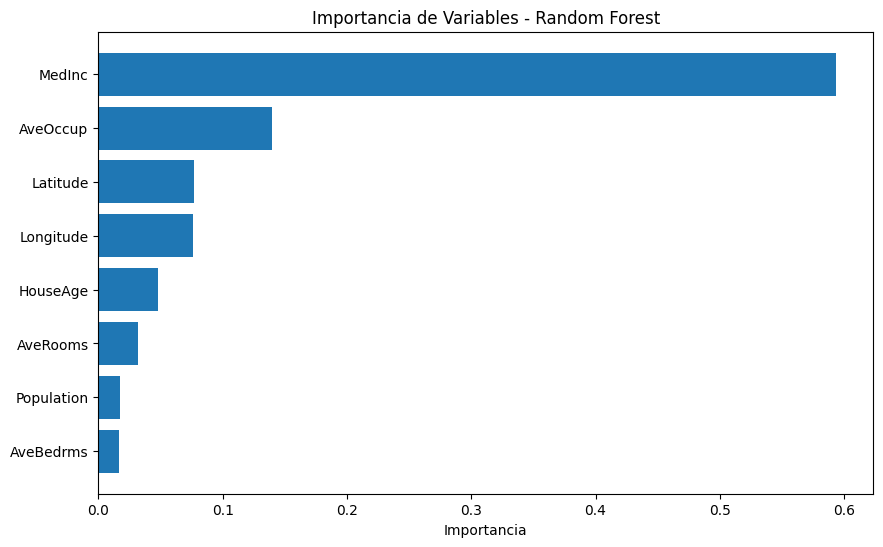

In [16]:

plt.barh(
    importance_rf["Variable"],
    importance_rf["Importancia"]
)

plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()



# 8. XGBoost

XGBoost utiliza boosting secuencial para mejorar errores.


In [17]:

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)


In [18]:

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print("RMSE:", rmse_xgb)
print("MAE :", mae_xgb)
print("R2  :", r2_xgb)


=== XGBoost ===
RMSE: 0.46498356263272245
MAE : 0.3095560662054715
R2  : 0.8350059278372314



## Feature Importance - XGBoost


In [19]:

importance_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importancia",
    ascending=False
)

importance_xgb


,Variable,Importancia
0,MedInc,0.354295
7,Longitude,0.139991
6,Latitude,0.131007
5,AveOccup,0.128264
2,AveRooms,0.122576
1,HouseAge,0.055103
3,AveBedrms,0.049643
4,Population,0.019122


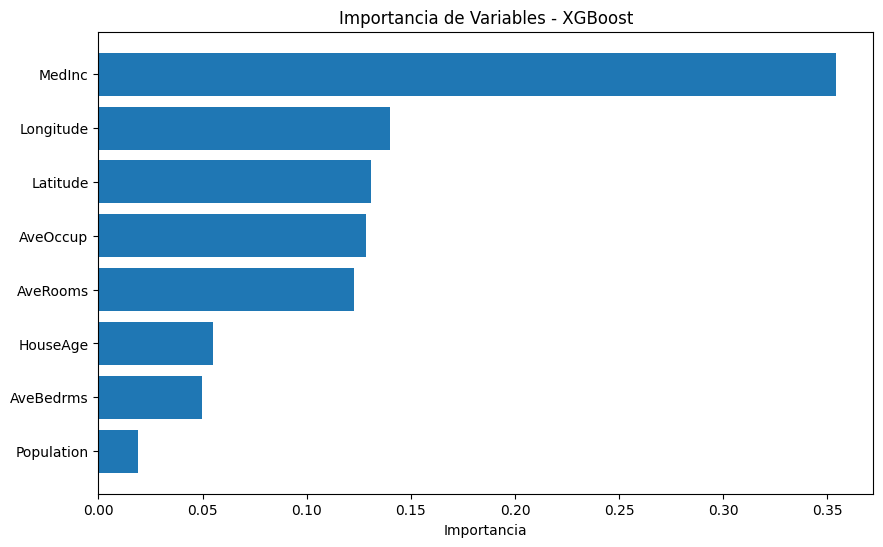

In [20]:

plt.barh(
    importance_xgb["Variable"],
    importance_xgb["Importancia"]
)

plt.title("Importancia de Variables - XGBoost")
plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()



# 9. Comparación de modelos


In [21]:

results = pd.DataFrame({
    "Modelo": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf,
        rmse_xgb
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf,
        mae_xgb
    ],
    "R2": [
        r2_linear,
        r2_tree,
        r2_rf,
        r2_xgb
    ]
})

results.sort_values(by="R2", ascending=False)


,Modelo,RMSE,MAE,R2
3,XGBoost,0.464984,0.309556,0.835006
2,Random Forest,0.544512,0.366289,0.773740
1,Decision Tree,0.724234,0.522259,0.599732
0,Linear Regression,0.745581,0.533200,0.575788


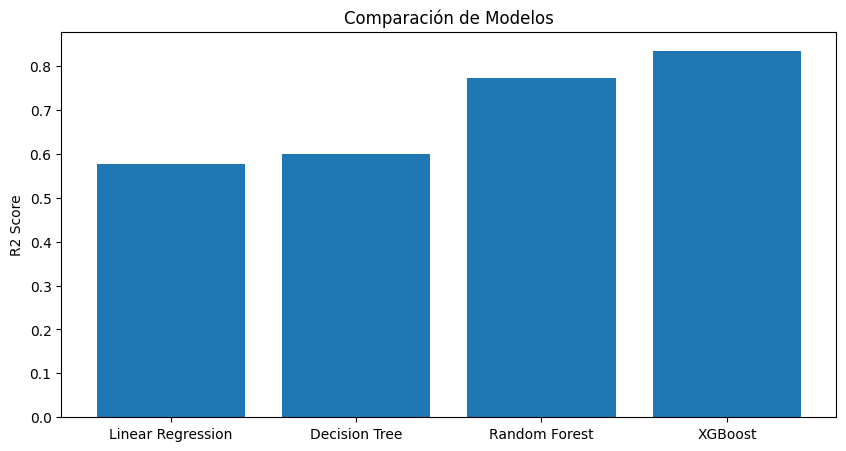

In [22]:

plt.figure(figsize=(10,5))

plt.bar(results["Modelo"], results["R2"])

plt.title("Comparación de Modelos")
plt.ylabel("R2 Score")

plt.show()



# 10. Conclusiones

## Observaciones

- La regresión lineal sirve como baseline.
- Los árboles capturan relaciones no lineales.
- Random Forest reduce overfitting respecto a un árbol individual.
- XGBoost suele obtener muy buen rendimiento en datos tabulares.

## Preguntas para clase

1. ¿Qué modelo obtuvo mejor R2?
2. ¿Qué variables parecen más importantes?
3. ¿Qué ventajas tiene Random Forest sobre un árbol?
4. ¿Por qué XGBoost suele funcionar tan bien?
5. ¿Qué riesgos de overfitting existen?
